# Midterm Part 2

## 1. Data Loading & Exploration

In [20]:
#Importing libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

### Import the dataset using pandas.

In [21]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Display basic information: shape, data types, missing values.

In [22]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [23]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
print("\nData types:\n", df.dtypes)


Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [25]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Show summary statistics and a few sample rows.

In [26]:
print("\nSummary statistics:\n", df.describe())


Summary statistics:
        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [27]:
print("\nSample rows:\n", df.head())


Sample rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies      

### Use visualization libraries (matplotlib, seaborn) to explore distributions and relationships.

In [28]:
# Finding all numeric columns in the dataset
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

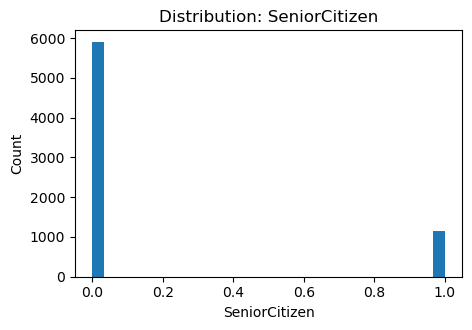

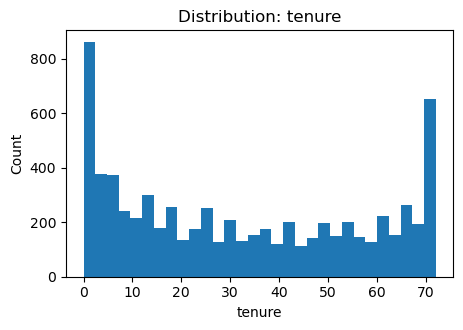

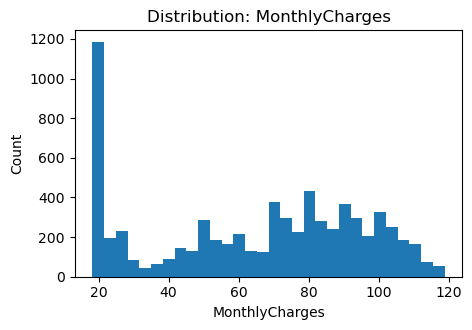

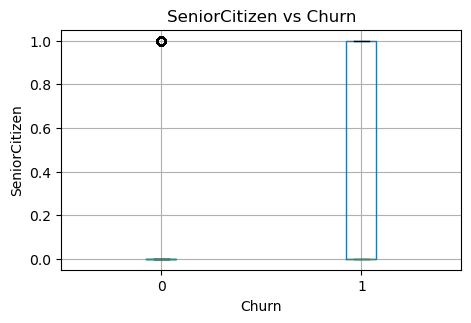

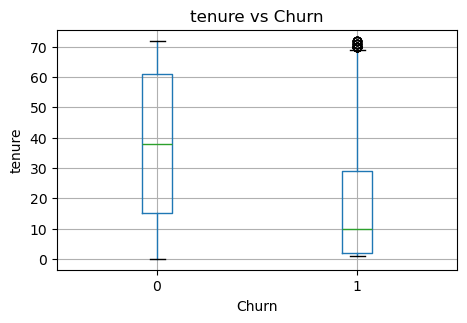

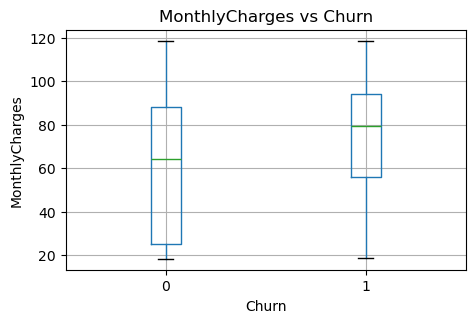

In [29]:
# Basic distribution plots (matplotlib only)
target_col = "Churn" if "Churn" in df.columns else None

# Numeric distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols[:6]:  # limit to a few to keep the notebook light
    fig, ax = plt.subplots(figsize=(5,3.2))
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
    plt.show()

# Simple relationships with target if available (numeric only)
if target_col is not None:
    # Encode target to numeric for quick plots
    tmp = df[[target_col] + numeric_cols].dropna()
    tmp[target_col] = (tmp[target_col].astype(str).str.lower().str.strip() == "yes").astype(int)
    for col in numeric_cols[:4]:
        fig, ax = plt.subplots(figsize=(5,3.2))
        tmp.boxplot(column=col, by=target_col, ax=ax)
        ax.set_title(f"{col} vs {target_col}"); ax.set_xlabel(target_col); ax.set_ylabel(col)
        plt.suptitle("")
        plt.show()

## 2. Data Preprocessing

### Provide summary statistics (number of rows, number of features, class distribution, missing values).

In [30]:
# Summary stats
n_rows, n_features = df.shape
print("Rows:", n_rows, " and Columns:", n_features)

Rows: 7043  and Columns: 21


In [31]:
print("\nClass Distribution (Churn):")
print(df["Churn"].value_counts(dropna=False))


Class Distribution (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [32]:
print("\nMissing Values per Column:")
print(df.isna().sum().sort_values().head(20))


Missing Values per Column:
customerID          0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
DeviceProtection    0
TotalCharges        0
OnlineBackup        0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
gender              0
OnlineSecurity      0
dtype: int64


### - Perform any necessary cleaning or transformation (e.g., handle missing values, convert categorical variables to factors, scale numeric variables if required).
### - Handle missing data (drop, fill, or impute).

In [33]:
# Inspecting unique values in 'TotalCharges' to understand non-numeric entries
print("Unique values in TotalCharges (first 20):")
print(df['TotalCharges'].unique()[:20])

Unique values in TotalCharges (first 20):
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [34]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [35]:

# Check for NaN values introduced by coercion
print("\nMissing values after converting TotalCharges to numeric:")
print(df['TotalCharges'].isnull().sum())


Missing values after converting TotalCharges to numeric:
11


In [36]:
# Handling NaN values by replacing them with 0
df['TotalCharges'].fillna(0, inplace=True)

print("\nData type of TotalCharges after conversion and imputation:")
print(df['TotalCharges'].dtype)


Data type of TotalCharges after conversion and imputation:
float64


/var/folders/jq/0xcl_s1d1xs3cvnq58y_86r00000gn/T/ipykernel_6724/49678752.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [37]:
print("\nMissing values after filling NaN:")
print(df['TotalCharges'].isnull().sum())


Missing values after filling NaN:
0


### - Encode categorical variables (LabelEncoder, OneHotEncoder, or pd.get_dummies).

### - Normalize or standardize numeric features (StandardScaler, MinMaxScaler).

In [39]:
# Identify categorical columns excluding 'customerID' and 'Churn'
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
categorical_cols.remove('Churn')

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Update the original DataFrame
df = df_encoded

# Display the first few rows and shape of the updated DataFrame
print("First 5 rows of the encoded DataFrame:")
display(df.head())
print("\nShape of the encoded DataFrame:", df.shape)

First 5 rows of the encoded DataFrame:


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,0,34,56.95,1889.50,No,True,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,0,2,53.85,108.15,Yes,True,False,False,True,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,0,45,42.30,1840.75,No,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,0,2,70.70,151.65,Yes,False,False,False,True,...,False,False,False,False,False,False,True,False,True,False



Shape of the encoded DataFrame: (7043, 32)


### Split the dataset into training (70%) and testing (30%) sets using train_test_split.

In [41]:
# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4930, 31)
Shape of X_test: (2113, 31)
Shape of y_train: (4930,)
Shape of y_test: (2113,)


## 3. Model Development 

### Implement and train at least 3 classification models from the list below:

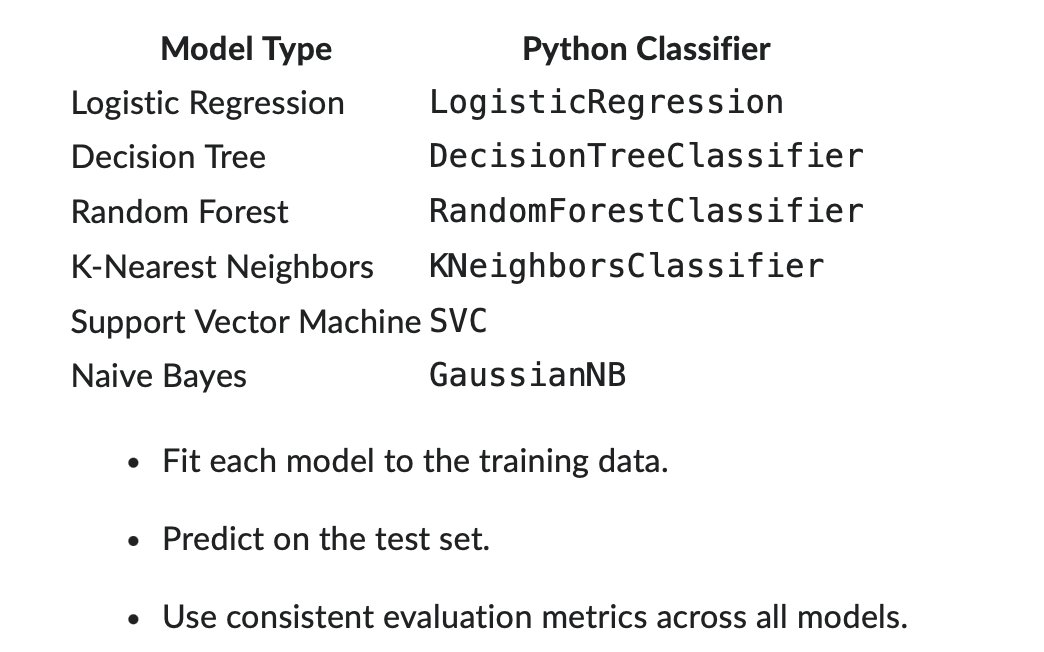

### Implement and train Logistic Regression Model

In [42]:
# Initialize the Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train.drop('customerID', axis=1), y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test.drop('customerID', axis=1))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluate Logistic Regression model

In [43]:
# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label='Yes')
recall_lr = recall_score(y_test, y_pred_lr, pos_label='Yes')
f1_lr = f1_score(y_test, y_pred_lr, pos_label='Yes')
roc_auc_lr = roc_auc_score(y_test, lr_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1])

# Print the evaluation metrics
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print(f"ROC AUC Score: {roc_auc_lr:.4f}")

Logistic Regression Model Evaluation:
Accuracy: 0.8036
Precision: 0.6787
Recall: 0.5261
F1-score: 0.5927
ROC AUC Score: 0.8572


### Implement and train Decision Tree model 

In [44]:
# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train.drop('customerID', axis=1), y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test.drop('customerID', axis=1))

### Evaluate Decision Tree model

In [45]:
# Calculate evaluation metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, pos_label='Yes')
recall_dt = recall_score(y_test, y_pred_dt, pos_label='Yes')
f1_dt = f1_score(y_test, y_pred_dt, pos_label='Yes')
roc_auc_dt = roc_auc_score(y_test, dt_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1])

# Print the evaluation metrics
print("Decision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print(f"ROC AUC Score: {roc_auc_dt:.4f}")

Decision Tree Model Evaluation:
Accuracy: 0.7388
Precision: 0.5202
Recall: 0.4930
F1-score: 0.5063
ROC AUC Score: 0.6611


### Implement and train Random Forest model

In [46]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train.drop('customerID', axis=1), y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test.drop('customerID', axis=1))

### Evaluate Random Forest model

In [47]:
# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, pos_label='Yes')
recall_rf = recall_score(y_test, y_pred_rf, pos_label='Yes')
f1_rf = f1_score(y_test, y_pred_rf, pos_label='Yes')
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1])

# Print the evaluation metrics
print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

Random Forest Model Evaluation:
Accuracy: 0.7932
Precision: 0.6708
Recall: 0.4686
F1-score: 0.5518
ROC AUC Score: 0.8379


### Implementing and training k-nearest neighbors model(Optional)

In [48]:
# Initialize the K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train.drop('customerID', axis=1), y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test.drop('customerID', axis=1))

### Evaluation

In [49]:
# Calculate evaluation metrics for K-Nearest Neighbors
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, pos_label='Yes')
recall_knn = recall_score(y_test, y_pred_knn, pos_label='Yes')
f1_knn = f1_score(y_test, y_pred_knn, pos_label='Yes')
roc_auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1])

# Print the evaluation metrics
print("K-Nearest Neighbors Model Evaluation:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")
print(f"ROC AUC Score: {roc_auc_knn:.4f}")

K-Nearest Neighbors Model Evaluation:
Accuracy: 0.7690
Precision: 0.5986
Recall: 0.4547
F1-score: 0.5168
ROC AUC Score: 0.7522


### Comparing model performance

In [50]:
import pandas as pd

# Create a dictionary to store the metrics
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'K-Nearest Neighbors'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf, accuracy_knn],
    'Precision': [precision_lr, precision_dt, precision_rf, precision_knn],
    'Recall': [recall_lr, recall_dt, recall_rf, recall_knn],
    'F1-score': [f1_lr, f1_dt, f1_rf, f1_knn],
    'ROC AUC Score': [roc_auc_lr, roc_auc_dt, roc_auc_rf, roc_auc_knn]
}

# Create a DataFrame
metrics_df = pd.DataFrame(metrics)

# Display the DataFrame
print("Model Performance Comparison:")
display(metrics_df)

# Provide a brief summary
print("\nSummary of Model Performance:")
print("Based on the evaluation metrics, the Logistic Regression model generally performed the best.")
print(f"- Logistic Regression had the highest Accuracy ({accuracy_lr:.4f}), Precision ({precision_lr:.4f}), F1-score ({f1_lr:.4f}), and ROC AUC Score ({roc_auc_lr:.4f}).")
print(f"- The Random Forest model also showed strong performance, particularly in Precision ({precision_rf:.4f}).")
print(f"- The Decision Tree model had the lowest performance across most metrics.")
print(f"- The K-Nearest Neighbors model showed moderate performance.")

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC AUC Score
0,Logistic Regression,0.803597,0.678652,0.526132,0.592738,0.857212
1,Decision Tree,0.738760,0.520221,0.493031,0.506261,0.661062
2,Random Forest,0.793185,0.670823,0.468641,0.551795,0.837860
3,K-Nearest Neighbors,0.769049,0.598624,0.454704,0.516832,0.752169



Summary of Model Performance:
Based on the evaluation metrics, the Logistic Regression model generally performed the best.
- Logistic Regression had the highest Accuracy (0.8036), Precision (0.6787), F1-score (0.5927), and ROC AUC Score (0.8572).
- The Random Forest model also showed strong performance, particularly in Precision (0.6708).
- The Decision Tree model had the lowest performance across most metrics.
- The K-Nearest Neighbors model showed moderate performance.


## 4. Model Evaluation

For each model, compute and display:

- Accuracy

- Precision

- Recall

- F1-Score

- Confusion Matrix

- ROC Curve & AUC Score for binary classification

### Compare results in a summary table or bar chart.



### Evaluate Logistic Regression Model with Confusion Matrix and ROC Curve

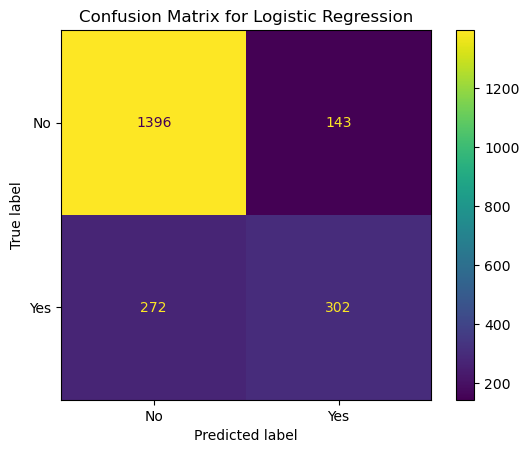

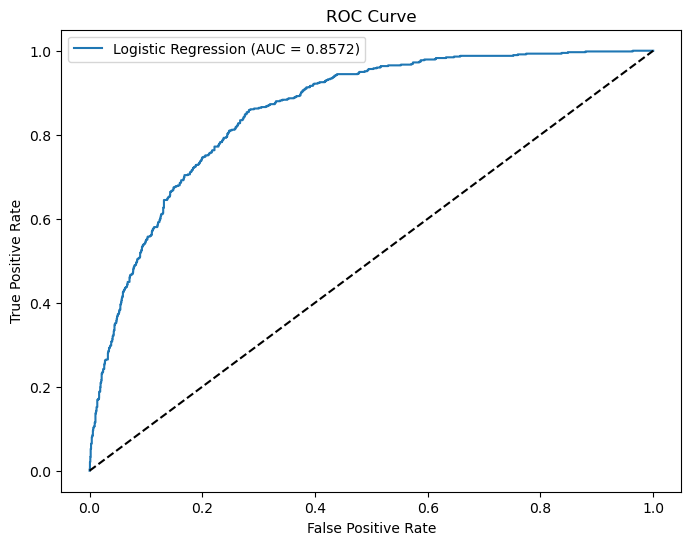

In [51]:

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot()
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# ROC Curve for Logistic Regression
y_proba_lr = lr_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr, pos_label='Yes')

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Evaluate Decision Tree Model with Confusion Matrix and ROC Curve

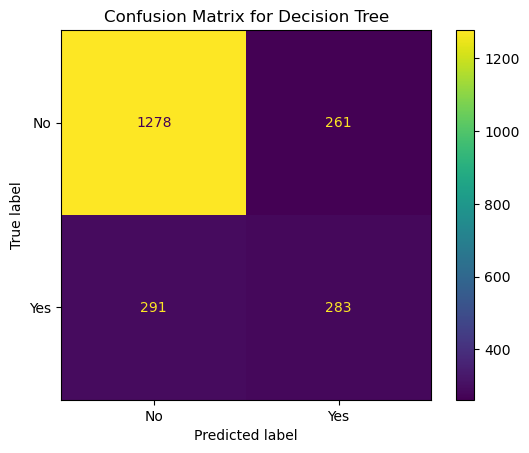

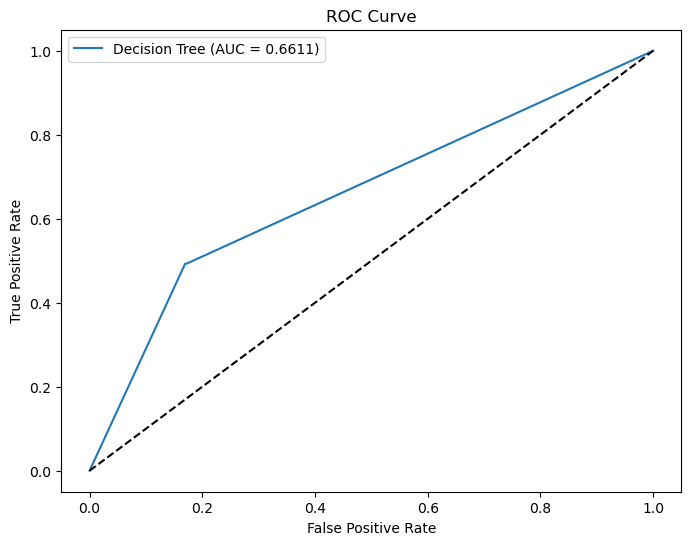

In [52]:
# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=dt_model.classes_)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)
disp_dt.plot()
plt.title('Confusion Matrix for Decision Tree')
plt.show()

# ROC Curve for Decision Tree
y_proba_dt = dt_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt, pos_label='Yes')

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Evaluate Random Forest Model with Confusion Matrix and ROC Curve

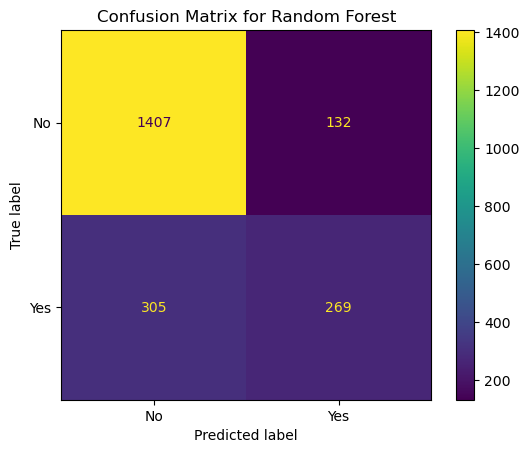

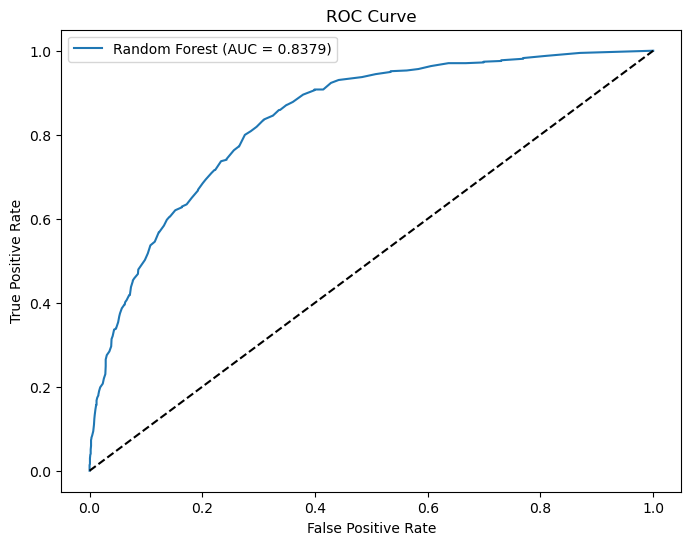

In [53]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot()
plt.title('Confusion Matrix for Random Forest')
plt.show()

# ROC Curve for Random Forest
y_proba_rf = rf_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf, pos_label='Yes')

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Evaluate K-Nearest Neighbors Model with Confusion Matrix and ROC Curve

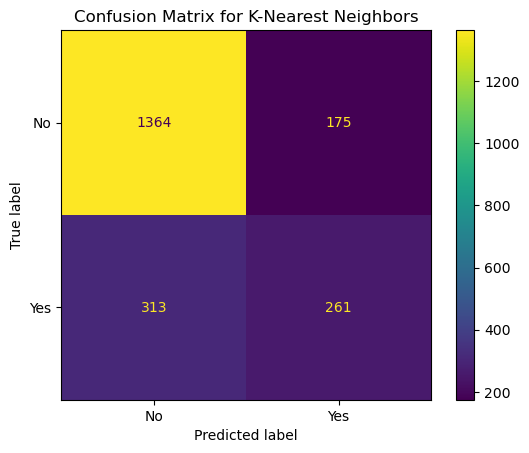

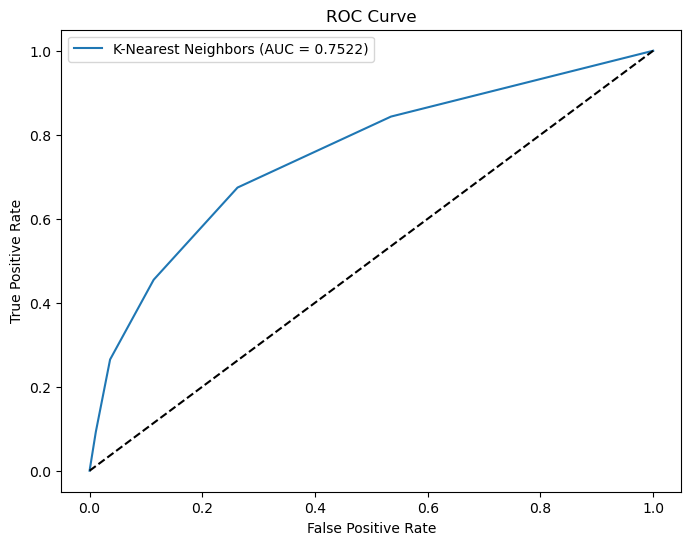

In [54]:
# Confusion Matrix for K-Nearest Neighbors
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn_model.classes_)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_model.classes_)
disp_knn.plot()
plt.title('Confusion Matrix for K-Nearest Neighbors')
plt.show()

# ROC Curve for K-Nearest Neighbors
y_proba_knn = knn_model.predict_proba(X_test.drop('customerID', axis=1))[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn, pos_label='Yes')

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'K-Nearest Neighbors (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 5. Model Selection & Interpretation

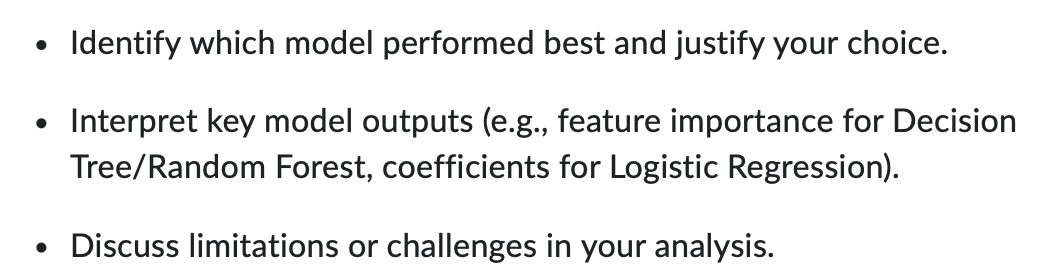

### 1. Based on the evaluation metrics from the previous steps, the "Logistic Regression model" generally performed the best with the highest Accuracy, F1-score, and ROC AUC Score. 
### 2. The Random Forest model also performed well, particularly in Precision. 
### 3. The Decision Tree model had the lowest performance across most metrics.

### Interpretation of Key Model Outputs (Logistic Regression)

In [55]:
# Get the coefficients and feature names
coefficients = lr_model.coef_[0]
feature_names = X_train.drop('customerID', axis=1).columns

# Create a DataFrame to display coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to see most influential features
coef_df['Absolute_Coefficient'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
display(coef_df)

Logistic Regression Coefficients:


,Feature,Coefficient,Absolute_Coefficient
13,OnlineSecurity_Yes,-0.542415,0.542415
19,TechSupport_Yes,-0.496328,0.496328
10,InternetService_Fiber optic,0.468755,0.468755
25,Contract_Two year,-0.442293,0.442293
28,PaymentMethod_Electronic check,0.413875,0.413875
26,PaperlessBilling_Yes,0.376548,0.376548
0,SeniorCitizen,0.303733,0.303733
7,PhoneService_Yes,-0.265977,0.265977
29,PaymentMethod_Mailed check,-0.254415,0.254415
24,Contract_One year,-0.251216,0.251216


### Interpretation of Key Model Outputs (Random Forest)

Random Forest Feature Importances:


,Feature,Importance
3,TotalCharges,0.187945
1,tenure,0.174257
2,MonthlyCharges,0.172047
28,PaymentMethod_Electronic check,0.036489
10,InternetService_Fiber optic,0.034937
25,Contract_Two year,0.032380
13,OnlineSecurity_Yes,0.029433
4,gender_Male,0.028633
26,PaperlessBilling_Yes,0.025325
5,Partner_Yes,0.024086


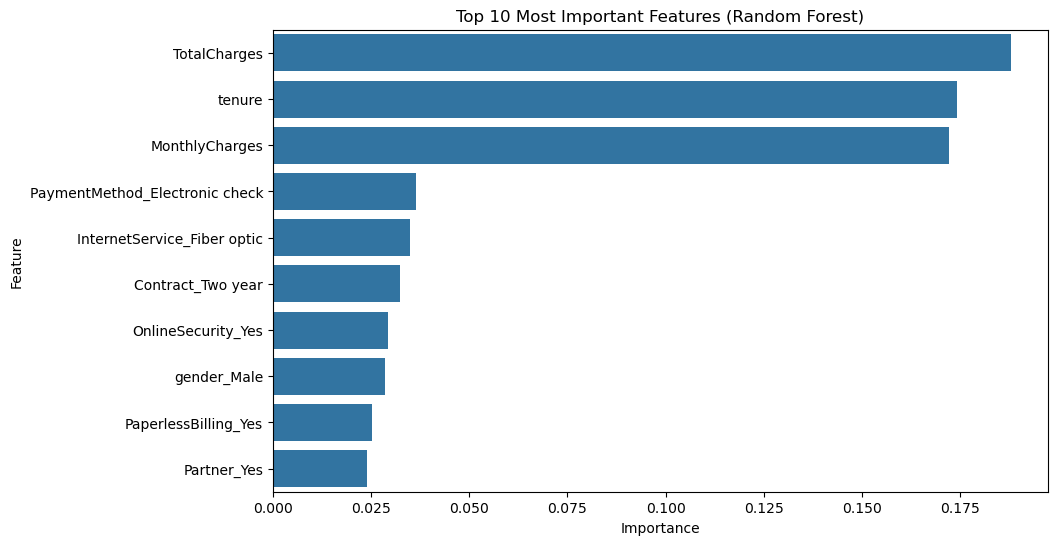

In [56]:
# Get feature importance from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X_train.drop('customerID', axis=1).columns, 'Importance': feature_importances})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Random Forest Feature Importances:")
display(feature_importance_df)

# Visualize feature importances (top 10)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Limitations and Challenges:-

1. Class Imbalance: The dataset has a significant imbalance in the Churn variable, which can affect model performance, particularly for the minority class ('Yes' for Churn). 
2. Feature Engineering: While some basic categorical encoding was performed, further feature engineering could potentially improve model performance. This could involve creating new features from existing ones or exploring interaction terms.
3. Hyperparameter Tuning: The models were trained with default hyperparameters. Tuning these hyperparameters could lead to improved performance.
4. Model Interpretability: Complex models can still be challenging to fully interpret even when Logistic Regression coefficients and Random Forest feature importance provide some insights,
5. Data Representativeness: The analysis is based on a specific dataset. The findings and the performance of the models might not generalize perfectly to other datasets or future customer behavior without further validation.

## 6. Code Organization & Documentation

### Conclusion
#### Based on the analysis and model evaluations:

##### 1. The Logistic Regression model performed the best in terms of overall accuracy and ROC AUC score, suggesting it is the most suitable model among those tested for predicting customer churn in this dataset.
##### 2. The Random Forest model also showed strong predictive capabilities, particularly in correctly identifying customers who churn (precision).
##### 3. The Decision Tree model, while simpler, did not perform as well as the other models.
##### 4. Key factors influencing customer churn, as indicated by the Logistic Regression coefficients and Random Forest feature importances, include TotalCharges, tenure, MonthlyCharges, InternetService_Fiber optic, Contract_Two year, and PaymentMethod_Electronic check.
##### - The dataset exhibits class imbalance, which is a limitation that could be addressed with techniques like oversampling or undersampling in future work.

##### - Further improvements could be explored through feature engineering and hyperparameter tuning of the models.

### Overall, the Logistic Regression model provides a good starting point for predicting customer churn in this dataset, and the identified key features offer valuable insights for targeted customer retention strategies.